# 02 - Exploratory Data Analysis (EDA)

El objetivo de este notebook es analizar el comportamiento de las principales variables del dataset, identificar distribuciones, valores atípicos y relaciones relevantes entre las características de los clientes.

El análisis servirá como base para tomar decisiones posteriores de limpieza, *feature engineering* y segmentación.

## Estructura

1. Carga del dataset
2. Perfil del cliente
3. Comportamiento de compra
4. Marketing y respuesta a campañas
5. Relaciones entre variables
6. Conclusiones


## 1. Carga del dataset


In [2]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


In [3]:
DATA_PATH = Path("../data/raw/marketing_campaign.csv")

df = pd.read_csv(DATA_PATH, sep="\t")


In [4]:
df["Dt_Customer"] = pd.to_datetime(
    df["Dt_Customer"],
    format="%d-%m-%Y"
)


## 2. Perfil del cliente

### 2.1 Año de nacimiento


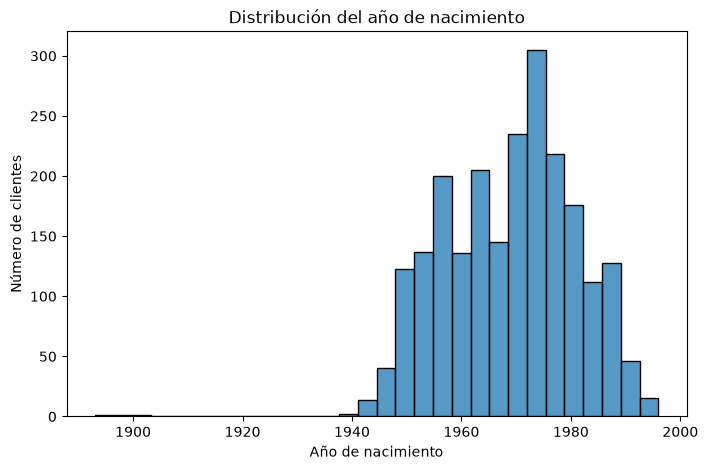

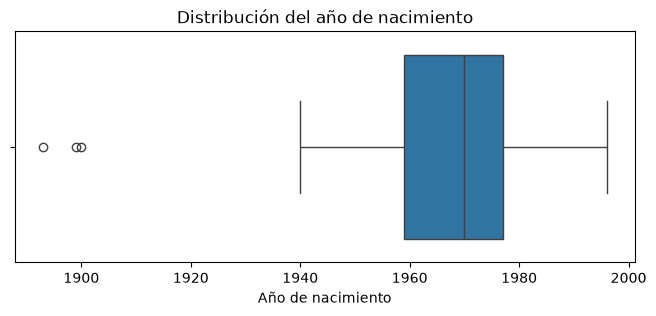

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Year_Birth",
    bins=30
)

plt.title("Distribución del año de nacimiento")
plt.xlabel("Año de nacimiento")
plt.ylabel("Número de clientes")

plt.show()

plt.figure(figsize=(8, 3))

sns.boxplot(
    data=df,
    x="Year_Birth"
)

plt.title("Distribución del año de nacimiento")
plt.xlabel("Año de nacimiento")

plt.show()


In [ ]:
df.nsmallest(10, "Year_Birth")[
    ["ID", "Year_Birth", "Education", "Marital_Status", "Income"]
]


,ID,Year_Birth,Education,Marital_Status,Income
239,11004,1893,2n Cycle,Single,60182.0
339,1150,1899,PhD,Together,83532.0
192,7829,1900,2n Cycle,Divorced,36640.0
1950,6663,1940,PhD,Single,51141.0
424,6932,1941,PhD,Married,93027.0
39,2968,1943,PhD,Divorced,48948.0
358,6142,1943,Master,Married,65073.0
415,7106,1943,PhD,Married,75865.0
894,8800,1943,PhD,Divorced,48948.0
1150,1453,1943,PhD,Widow,57513.0


### Año de nacimiento

La distribución de `Year_Birth` presenta tres observaciones claramente
separadas del resto del dataset, correspondientes a los años 1893, 1899 y
1900.

La siguiente observación corresponde a 1940, generándose un salto de 40 años
entre ambos grupos. Estos tres registros se consideran candidatos a valores
atípicos y su tratamiento se decidirá durante la fase de preparación de datos.

No se eliminan observaciones durante esta fase exploratoria.


### 2.2 Ingresos


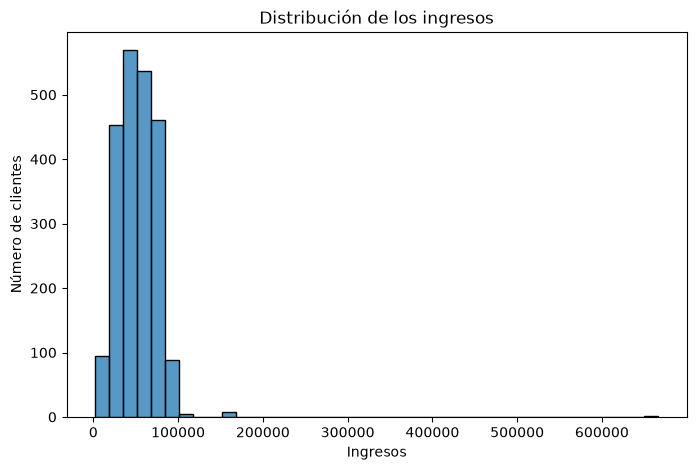

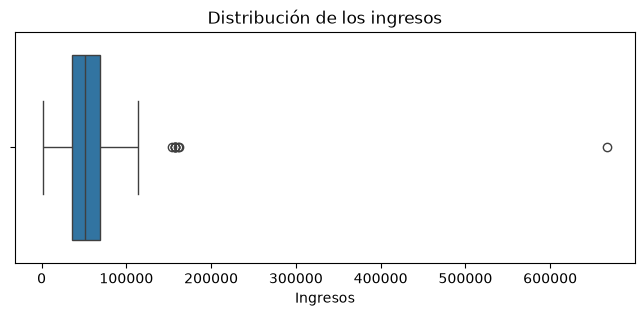

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Income",
    bins=40,
    ax=ax
)

ax.set_title("Distribución de los ingresos")
ax.set_xlabel("Ingresos")
ax.set_ylabel("Número de clientes")

plt.show()

fig, ax = plt.subplots(figsize=(8, 3))

sns.boxplot(
    data=df,
    x="Income",
    ax=ax
)

ax.set_title("Distribución de los ingresos")
ax.set_xlabel("Ingresos")

plt.show()


In [8]:
df.nlargest(10, "Income")[
    [
        "ID",
        "Year_Birth",
        "Education",
        "Marital_Status",
        "Income"
    ]
]


,ID,Year_Birth,Education,Marital_Status,Income
2233,9432,1977,Graduation,Together,666666.0
617,1503,1976,PhD,Together,162397.0
687,1501,1982,PhD,Married,160803.0
1300,5336,1971,Master,Together,157733.0
164,8475,1973,PhD,Married,157243.0
1653,4931,1977,Graduation,Together,157146.0
2132,11181,1949,PhD,Married,156924.0
655,5555,1975,Graduation,Divorced,153924.0
1898,4619,1945,PhD,Single,113734.0
646,4611,1970,Graduation,Together,105471.0


In [9]:
q1 = df["Income"].quantile(0.25)
q3 = df["Income"].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print(f"Q1: {q1:.2f}")
print(f"Q3: {q3:.2f}")
print(f"IQR: {iqr:.2f}")
print(f"Límite inferior: {lower_bound:.2f}")
print(f"Límite superior: {upper_bound:.2f}")


Q1: 35303.00
Q3: 68522.00
IQR: 33219.00
Límite inferior: -14525.50
Límite superior: 118350.50


In [10]:
income_outliers = df[
    (df["Income"] < lower_bound)
    | (df["Income"] > upper_bound)
]

income_outliers[
    ["ID", "Income"]
].sort_values("Income")


,ID,Income
655,5555,153924.0
2132,11181,156924.0
1653,4931,157146.0
164,8475,157243.0
1300,5336,157733.0
687,1501,160803.0
617,1503,162397.0
2233,9432,666666.0


### Ingresos

La distribución de `Income` se concentra principalmente en valores inferiores
a 100.000, aunque presenta una cola hacia valores elevados.

Mediante el criterio del rango intercuartílico (IQR), se obtiene un límite
superior de 118.350,50. Se identifican 8 observaciones por encima de este
umbral.

Siete de ellas presentan ingresos entre aproximadamente 154.000 y 162.000,
mientras que una observación alcanza 666.666, situándose muy alejada tanto
de la distribución principal como del resto de valores atípicos.

El criterio IQR identifica observaciones estadísticamente atípicas, pero no
implica que sean datos incorrectos. Su tratamiento se decidirá posteriormente
durante la preparación de los datos.


In [11]:
df.nlargest(8, "Income")[
    [
        "ID",
        "Year_Birth",
        "Education",
        "Marital_Status",
        "Income",
        "MntWines",
        "MntMeatProducts",
        "NumWebPurchases",
        "NumCatalogPurchases",
        "NumStorePurchases"
    ]
]


,ID,Year_Birth,Education,Marital_Status,Income,MntWines,MntMeatProducts,NumWebPurchases,NumCatalogPurchases,NumStorePurchases
2233,9432,1977,Graduation,Together,666666.0,9,18,3,1,3
617,1503,1976,PhD,Together,162397.0,85,16,0,0,1
687,1501,1982,PhD,Married,160803.0,55,1622,0,28,1
1300,5336,1971,Master,Together,157733.0,39,9,1,0,1
164,8475,1973,PhD,Married,157243.0,20,1582,0,22,0
1653,4931,1977,Graduation,Together,157146.0,1,1725,0,28,0
2132,11181,1949,PhD,Married,156924.0,2,2,0,0,0
655,5555,1975,Graduation,Divorced,153924.0,1,1,0,0,0


### 2.3 Educación y estado civil


In [ ]:
education_counts = df["Education"].value_counts()
marital_counts = df["Marital_Status"].value_counts()

education_counts, marital_counts


(Education
 Graduation    1127
 PhD            486
 Master         370
 2n Cycle       203
 Basic           54
 Name: count, dtype: int64,
 Marital_Status
 Married     864
 Together    580
 Single      480
 Divorced    232
 Widow        77
 Alone         3
 Absurd        2
 YOLO          2
 Name: count, dtype: int64)

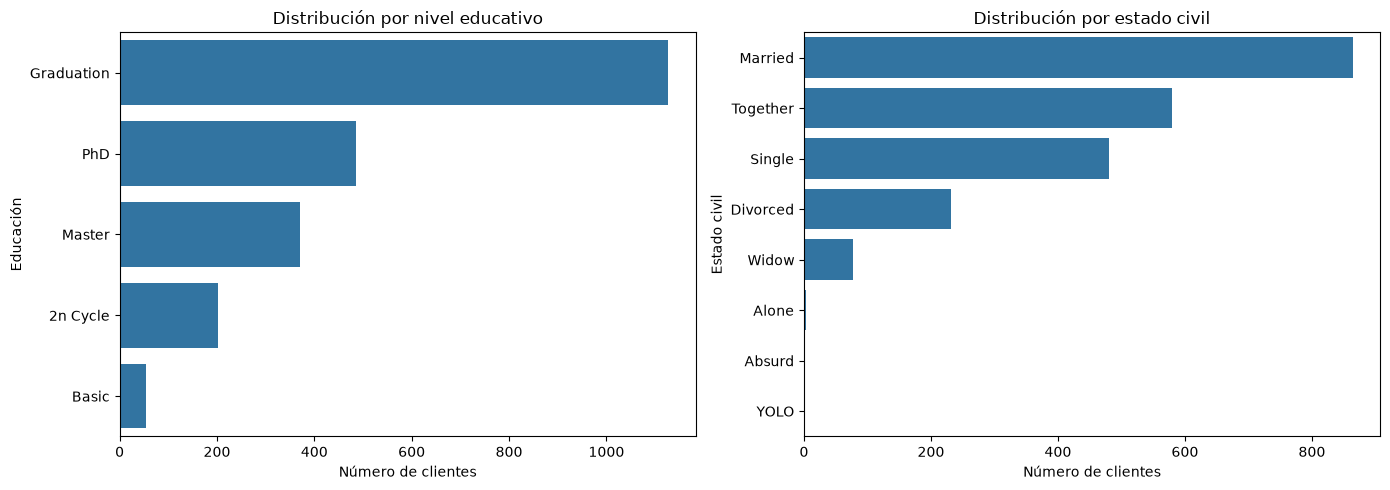

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=df,
    y="Education",
    order=df["Education"].value_counts().index,
    ax=axes[0]
)

axes[0].set_title("Distribución por nivel educativo")
axes[0].set_xlabel("Número de clientes")
axes[0].set_ylabel("Educación")

sns.countplot(
    data=df,
    y="Marital_Status",
    order=df["Marital_Status"].value_counts().index,
    ax=axes[1]
)

axes[1].set_title("Distribución por estado civil")
axes[1].set_xlabel("Número de clientes")
axes[1].set_ylabel("Estado civil")

plt.tight_layout()
plt.show()


### Perfil sociodemográfico

La categoría educativa predominante es `Graduation`, seguida de `PhD` y
`Master`. `Basic` presenta una frecuencia considerablemente menor, aunque
mantiene un número suficiente de observaciones para su análisis.

En `Marital_Status`, la mayor parte de los clientes se concentra en las
categorías `Married`, `Together`, `Single`, `Divorced` y `Widow`.

Las categorías `Alone`, `Absurd` y `YOLO` presentan únicamente 7 registros
en conjunto. Debido a su escasa frecuencia y, en algunos casos, a su
interpretación poco clara, se consideran candidatas a revisión durante la
fase de preparación de datos.


## 3. Comportamiento de compra

### 3.1 Gasto por categoría de producto


In [ ]:
spending_cols = [
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds"
]


In [15]:
df[spending_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
MntWines,2240.0,303.935714,336.597393,0.0,23.75,173.5,504.25,1493.0
MntFruits,2240.0,26.302232,39.773434,0.0,1.00,8.0,33.00,199.0
MntMeatProducts,2240.0,166.950000,225.715373,0.0,16.00,67.0,232.00,1725.0
MntFishProducts,2240.0,37.525446,54.628979,0.0,3.00,12.0,50.00,259.0
MntSweetProducts,2240.0,27.062946,41.280498,0.0,1.00,8.0,33.00,263.0
MntGoldProds,2240.0,44.021875,52.167439,0.0,9.00,24.0,56.00,362.0


In [16]:
df[spending_cols].mean().sort_values(ascending=False)


MntWines            303.935714
MntMeatProducts     166.950000
MntGoldProds         44.021875
MntFishProducts      37.525446
MntSweetProducts     27.062946
MntFruits            26.302232
dtype: float64

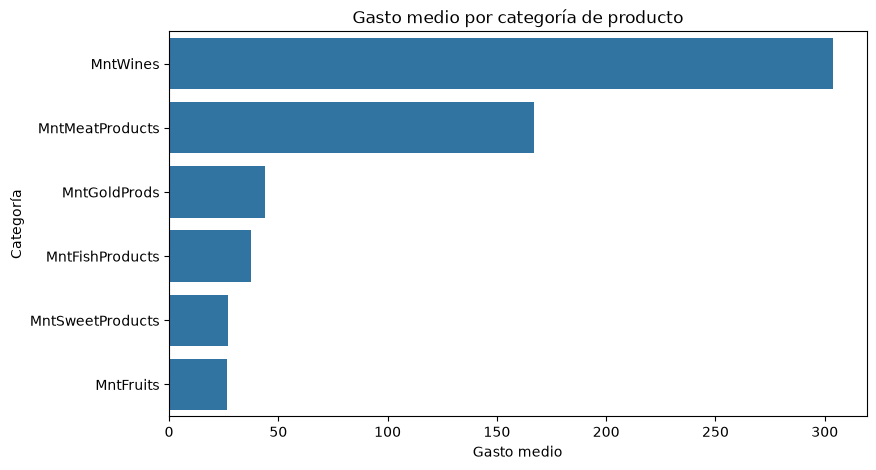

In [17]:
mean_spending = (
    df[spending_cols]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

sns.barplot(
    x=mean_spending.values,
    y=mean_spending.index
)

plt.title("Gasto medio por categoría de producto")
plt.xlabel("Gasto medio")
plt.ylabel("Categoría")

plt.show()


In [18]:
spending_long = df[spending_cols].melt(
    var_name="Category",
    value_name="Spending"
)

spending_long.head()


,Category,Spending
0,MntWines,635
1,MntWines,11
2,MntWines,426
3,MntWines,11
4,MntWines,173


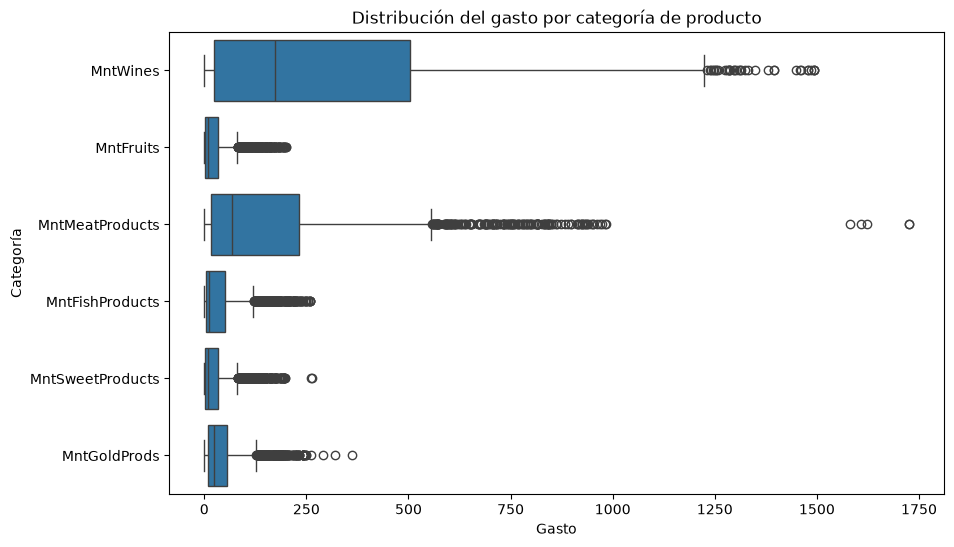

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=spending_long, x="Spending", y="Category")
plt.title("Distribución del gasto por categoría de producto")
plt.xlabel("Gasto")
plt.ylabel("Categoría")
plt.show()


### Distribución del gasto por categoría

Los boxplots muestran diferencias importantes tanto en el nivel como en la
dispersión del gasto entre categorías. El gasto en vino presenta los valores
más elevados, seguido del gasto en productos cárnicos.

Todas las categorías presentan distribuciones asimétricas hacia la derecha,
con observaciones situadas considerablemente por encima de sus respectivos
rangos intercuartílicos. Este comportamiento es especialmente visible en
`MntWines` y `MntMeatProducts`.

Estas observaciones no se consideran automáticamente errores, ya que pueden
representar clientes con niveles de consumo elevados. No obstante, deberán
tenerse en cuenta durante la preparación de los datos, especialmente antes
de aplicar algoritmos basados en distancias como K-Means.


### 3.2 Compras por canal


In [ ]:
purchase_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumDealsPurchases"
]


In [21]:
df[purchase_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
NumWebPurchases,2240.0,4.084821,2.778714,0.0,2.0,4.0,6.0,27.0
NumCatalogPurchases,2240.0,2.662054,2.923101,0.0,0.0,2.0,4.0,28.0
NumStorePurchases,2240.0,5.790179,3.250958,0.0,3.0,5.0,8.0,13.0
NumDealsPurchases,2240.0,2.325000,1.932238,0.0,1.0,2.0,3.0,15.0


### Comportamiento de compra por canal

La tienda física presenta el mayor número de compras por cliente, con una
media de 5,79, seguida del canal web (4,08) y del catálogo (2,66).

Las distribuciones de compras por canal presentan medias y medianas
relativamente próximas, aunque se observan algunos valores elevados,
especialmente en los canales web y catálogo.

`NumDealsPurchases` registra las compras realizadas utilizando descuentos y
no representa un canal de venta independiente. Por este motivo, se analizará
como una característica adicional del comportamiento de compra y no como un
canal equivalente a web, catálogo o tienda.


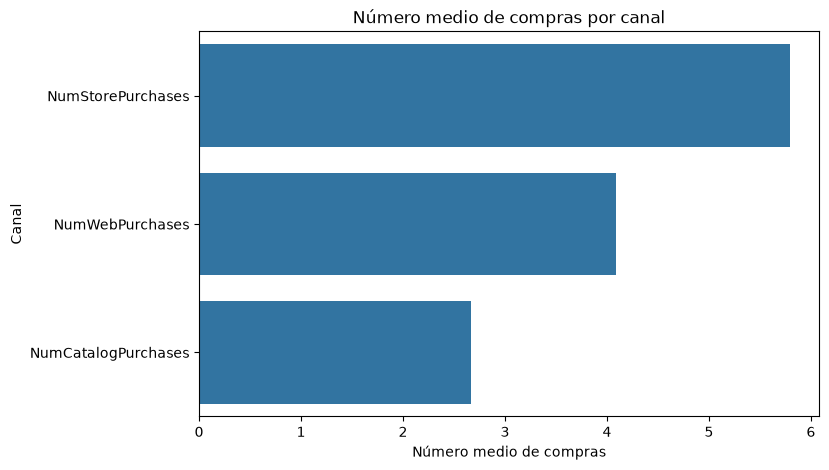

In [22]:
channel_cols = [
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases"
]

mean_purchases = (
    df[channel_cols]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=mean_purchases.values,
    y=mean_purchases.index
)

plt.title("Número medio de compras por canal")
plt.xlabel("Número medio de compras")
plt.ylabel("Canal")

plt.show()


### 3.3 Descuentos y comportamiento digital


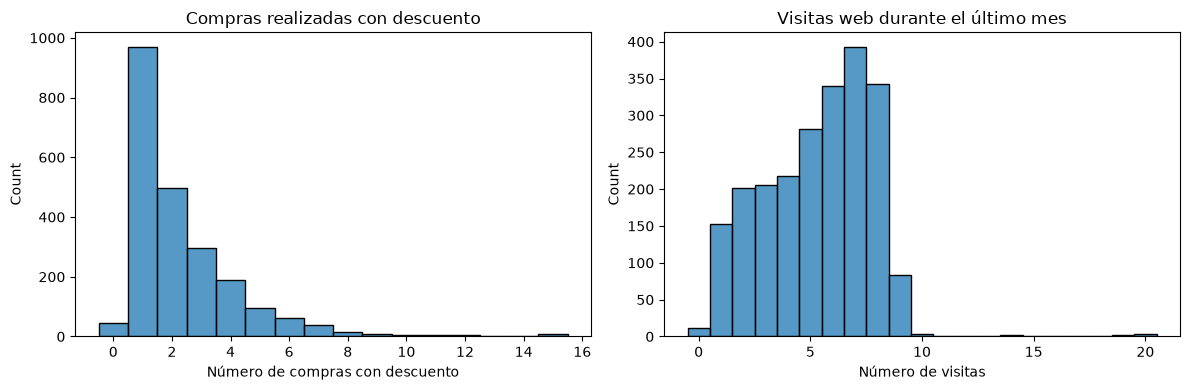

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(
    data=df,
    x="NumDealsPurchases",
    discrete=True,
    ax=axes[0]
)
axes[0].set_title("Compras realizadas con descuento")
axes[0].set_xlabel("Número de compras con descuento")

sns.histplot(
    data=df,
    x="NumWebVisitsMonth",
    discrete=True,
    ax=axes[1]
)
axes[1].set_title("Visitas web durante el último mes")
axes[1].set_xlabel("Número de visitas")

plt.tight_layout()
plt.show()


### 3.4 Recencia de compra


In [25]:
df["Recency"].describe()


count    2240.000000
mean       49.109375
std        28.962453
min         0.000000
25%        24.000000
50%        49.000000
75%        74.000000
max        99.000000
Name: Recency, dtype: float64

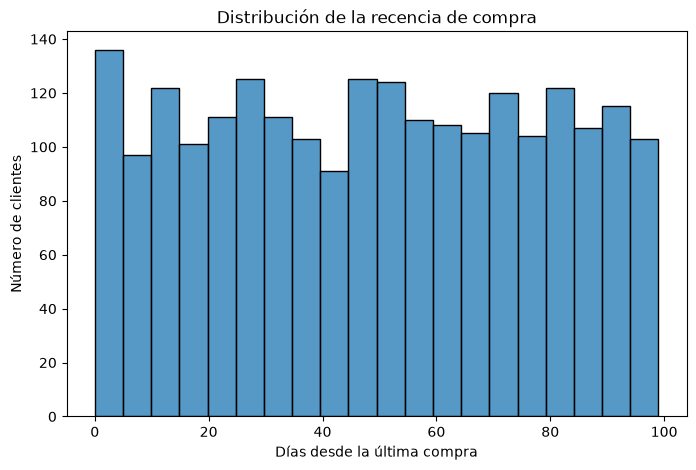

In [26]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Recency",
    bins=20
)

plt.title("Distribución de la recencia de compra")
plt.xlabel("Días desde la última compra")
plt.ylabel("Número de clientes")

plt.show()


### Recencia de compra

`Recency` presenta valores comprendidos entre 0 y 99 días, con una mediana
de 49 días y una media de aproximadamente 49,1 días.

La distribución se encuentra relativamente repartida a lo largo de todo el
rango, sin mostrar una asimetría pronunciada ni valores extremos claramente
diferenciados.

Esta variable será especialmente relevante para el posterior análisis RFM,
donde valores bajos de recencia representan clientes que han realizado una
compra más recientemente.


## 4. Marketing y respuesta a campañas

### 4.1 Tasas de aceptación de campañas


In [ ]:
campaign_cols = [
    "AcceptedCmp1",
    "AcceptedCmp2",
    "AcceptedCmp3",
    "AcceptedCmp4",
    "AcceptedCmp5",
    "Response"
]


In [28]:
campaign_acceptance = (
    df[campaign_cols]
    .mean()
    .sort_values(ascending=False)
)

campaign_acceptance


Response        0.149107
AcceptedCmp4    0.074554
AcceptedCmp3    0.072768
AcceptedCmp5    0.072768
AcceptedCmp1    0.064286
AcceptedCmp2    0.013393
dtype: float64

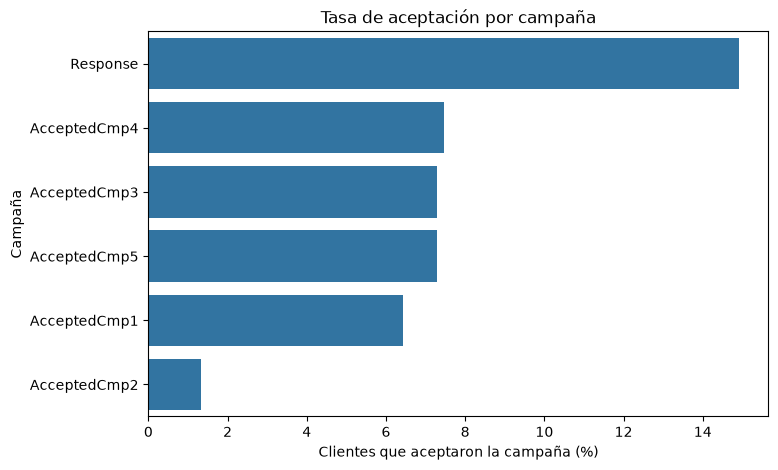

In [29]:
campaign_acceptance_pct = campaign_acceptance * 100

plt.figure(figsize=(8, 5))

sns.barplot(
    x=campaign_acceptance_pct.values,
    y=campaign_acceptance_pct.index
)

plt.title("Tasa de aceptación por campaña")
plt.xlabel("Clientes que aceptaron la campaña (%)")
plt.ylabel("Campaña")

plt.show()


### Respuesta a campañas de marketing

La última campaña, representada por `Response`, presenta la mayor tasa de
respuesta, con aproximadamente un 14,9 % de los clientes.

Las campañas anteriores muestran tasas de aceptación considerablemente
inferiores, situadas aproximadamente entre el 6 % y el 7,5 %, con la
excepción de `AcceptedCmp2`, cuya tasa de aceptación es de apenas un 1,3 %.

Estos resultados muestran diferencias importantes entre campañas, aunque
el dataset no proporciona información suficiente sobre su diseño, coste,
segmentación o periodo de ejecución para determinar las causas de estas
diferencias.


### 4.2 Ingresos y respuesta a la última campaña


In [30]:
df.groupby("Response")["Income"].describe()


,count,mean,std,min,25%,50%,75%,max
Response,,,,,,,,
0,1883.0,50839.132767,25252.804747,1730.0,34421.0,50150.0,66308.0,666666.0
1,333.0,60209.675676,23194.080987,7500.0,39763.0,64090.0,80589.0,105471.0


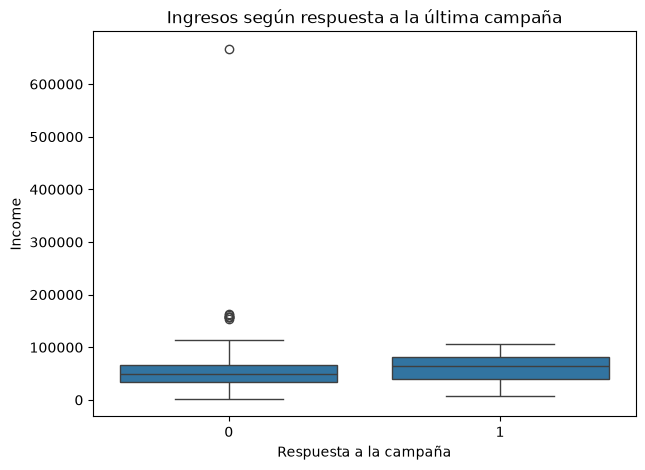

In [ ]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="Response",
    y="Income"
)

plt.title("Ingresos según respuesta a la última campaña")
plt.xlabel("Respuesta a la campaña")
plt.ylabel("Ingresos")

plt.show()


### Ingresos y respuesta a la última campaña

Los clientes que respondieron a la última campaña presentan niveles de
ingresos superiores en términos descriptivos. La mediana de `Income` es de
aproximadamente 64.090 entre los clientes que respondieron, frente a 50.150
entre quienes no respondieron.

La distribución de ingresos del grupo `Response = 1` se encuentra desplazada
hacia valores superiores. No obstante, esta relación debe interpretarse como
una asociación y no como evidencia de causalidad.

El grupo que no respondió contiene además el valor extremo `Income = 666666`,
identificado previamente durante el análisis exploratorio.


### 4.3 Gasto y respuesta a la última campaña


In [32]:
spending_by_response = (
    df.groupby("Response")[spending_cols]
    .median()
    .T
)

spending_by_response


Response,0,1
MntWines,152.0,448.0
MntFruits,7.0,21.0
MntMeatProducts,56.0,174.5
MntFishProducts,11.0,25.0
MntSweetProducts,7.0,20.0
MntGoldProds,21.0,39.5


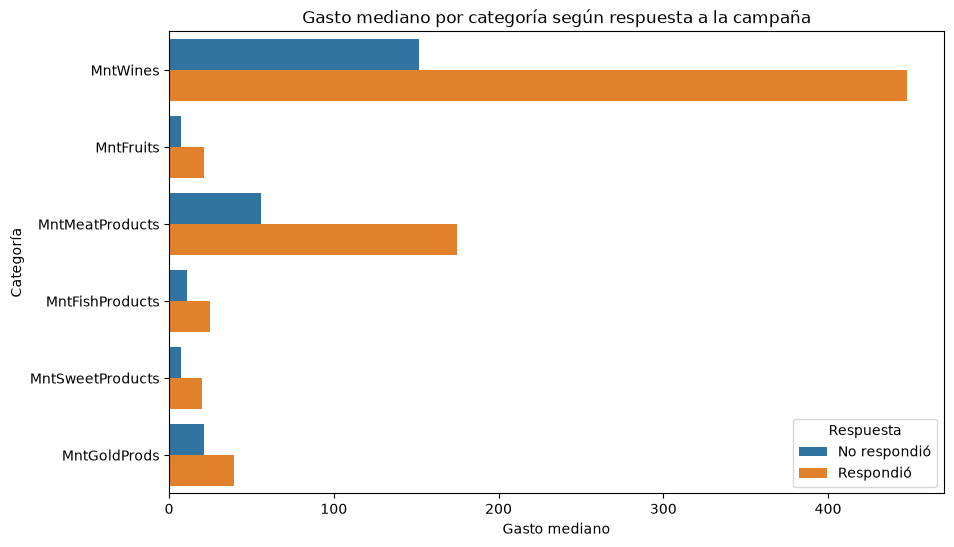

In [33]:
spending_response_long = (
    spending_by_response
    .reset_index()
    .melt(id_vars="index", var_name="Response", value_name="MedianSpending")
    .rename(columns={"index": "Category"})
)

spending_response_long["Response"] = spending_response_long["Response"].map({
    0: "No respondió",
    1: "Respondió"
})

plt.figure(figsize=(10, 6))
sns.barplot(
    data=spending_response_long,
    x="MedianSpending",
    y="Category",
    hue="Response"
)
plt.title("Gasto mediano por categoría según respuesta a la campaña")
plt.xlabel("Gasto mediano")
plt.ylabel("Categoría")
plt.legend(title="Respuesta")
plt.show()


### Gasto y respuesta a la última campaña

Los clientes que respondieron a la última campaña presentan un gasto mediano
superior en todas las categorías de producto analizadas.

Las mayores diferencias absolutas se observan en vino y productos cárnicos.
La mediana del gasto en vino aumenta de 152 entre quienes no respondieron a
448 entre quienes sí respondieron, mientras que en productos cárnicos pasa
de 56 a 174,5.

En términos descriptivos, los clientes que respondieron a la campaña muestran
un perfil de consumo más elevado. Este resultado representa una asociación
y no permite establecer una relación causal entre el nivel de gasto y la
respuesta a la campaña.


### 4.4 Perfil sociodemográfico y respuesta


In [34]:
response_by_education = (
    df.groupby("Education")["Response"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

response_by_education["mean"] *= 100

response_by_education


,mean,count
Education,,
PhD,20.781893,486
Master,15.405405,370
Graduation,13.487134,1127
2n Cycle,10.837438,203
Basic,3.703704,54


In [35]:
response_by_marital = (
    df.groupby("Marital_Status")["Response"]
    .agg(["mean", "count"])
    .sort_values("mean", ascending=False)
)

response_by_marital["mean"] *= 100

response_by_marital


,mean,count
Marital_Status,,
Absurd,50.000000,2
YOLO,50.000000,2
Alone,33.333333,3
Widow,24.675325,77
Single,22.083333,480
Divorced,20.689655,232
Married,11.342593,864
Together,10.344828,580


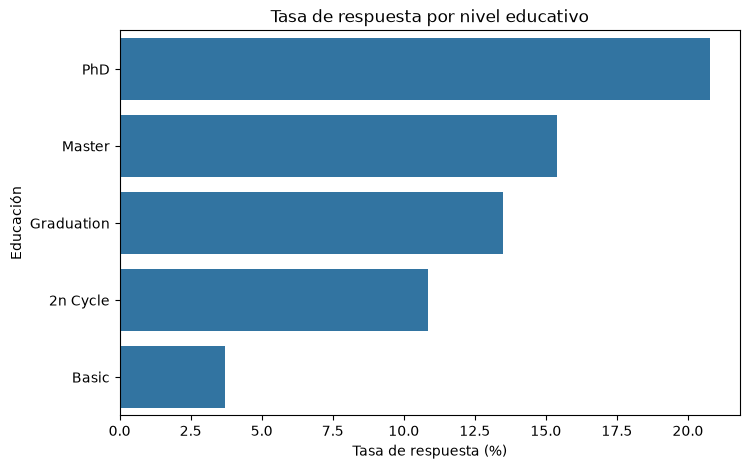

In [36]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=response_by_education["mean"],
    y=response_by_education.index
)

plt.title("Tasa de respuesta por nivel educativo")
plt.xlabel("Tasa de respuesta (%)")
plt.ylabel("Educación")

plt.show()


### Perfil sociodemográfico y respuesta a la campaña

La tasa de respuesta presenta diferencias según el nivel educativo. Los
clientes con `PhD` muestran la mayor tasa de respuesta (20,8 %), seguidos
por `Master` (15,4 %) y `Graduation` (13,5 %). La categoría `Basic`
presenta la menor tasa (3,7 %).

También se observan diferencias según el estado civil. Entre las categorías
con un número relevante de observaciones, `Widow`, `Single` y `Divorced`
presentan mayores tasas de respuesta que `Married` y `Together`.

Las elevadas tasas observadas en `Absurd`, `YOLO` y `Alone` no deben
interpretarse de forma equivalente, ya que estas categorías contienen
únicamente 2, 2 y 3 clientes, respectivamente. Su tratamiento se evaluará
durante la preparación de los datos.

Estas diferencias son descriptivas y no implican relaciones causales.


## 5. Relaciones entre variables

### 5.1 Actividad web y compras online


In [ ]:
df[["NumWebVisitsMonth", "NumWebPurchases"]].describe().T


,count,mean,std,min,25%,50%,75%,max
NumWebVisitsMonth,2240.0,5.316518,2.426645,0.0,3.0,6.0,7.0,20.0
NumWebPurchases,2240.0,4.084821,2.778714,0.0,2.0,4.0,6.0,27.0


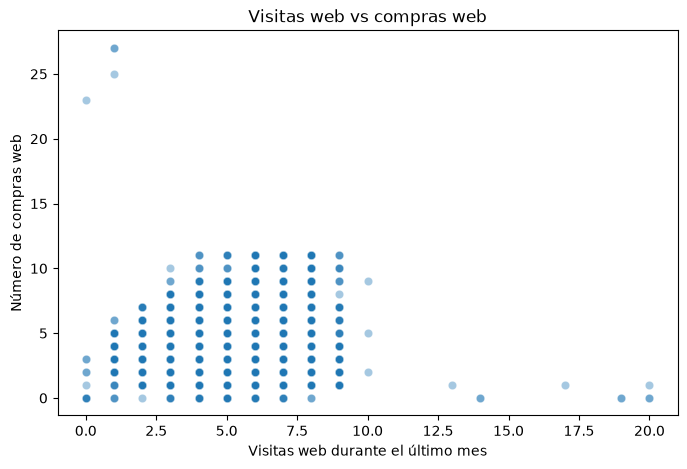

In [42]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="NumWebVisitsMonth",
    y="NumWebPurchases",
    alpha=0.4
)

plt.title("Visitas web vs compras web")
plt.xlabel("Visitas web durante el último mes")
plt.ylabel("Número de compras web")

plt.show()


In [43]:
pearson_corr = df["NumWebVisitsMonth"].corr(df["NumWebPurchases"])
spearman_corr = df["NumWebVisitsMonth"].corr(
    df["NumWebPurchases"],
    method="spearman"
)

print(f"Pearson: {pearson_corr:.3f}")
print(f"Spearman: {spearman_corr:.3f}")


Pearson: -0.056
Spearman: -0.097


### Actividad web y compras online

La relación entre `NumWebVisitsMonth` y `NumWebPurchases` presenta una
correlación de Pearson de aproximadamente -0,056 y una correlación de
Spearman de aproximadamente -0,097.

Ambos coeficientes se encuentran próximos a cero, por lo que no se observa
una asociación lineal ni monotónica relevante entre las dos variables.

El diagrama de dispersión tampoco muestra un patrón claro. Por tanto, una
mayor frecuencia de visitas durante el último mes no está asociada de forma
evidente con un mayor número de compras web en los datos disponibles.

La comparación debe interpretarse con cautela porque `NumWebVisitsMonth`
hace referencia explícitamente al último mes, mientras que no puede
confirmarse que `NumWebPurchases` corresponda al mismo periodo temporal.
Por ello, estas variables no permiten estimar directamente una tasa de
conversión.


### 5.2 Matriz de correlaciones


In [ ]:
corr_cols = [
    "Income",
    "Recency",
    "MntWines",
    "MntFruits",
    "MntMeatProducts",
    "MntFishProducts",
    "MntSweetProducts",
    "MntGoldProds",
    "NumDealsPurchases",
    "NumWebPurchases",
    "NumCatalogPurchases",
    "NumStorePurchases",
    "NumWebVisitsMonth"
]

corr_matrix = df[corr_cols].corr()


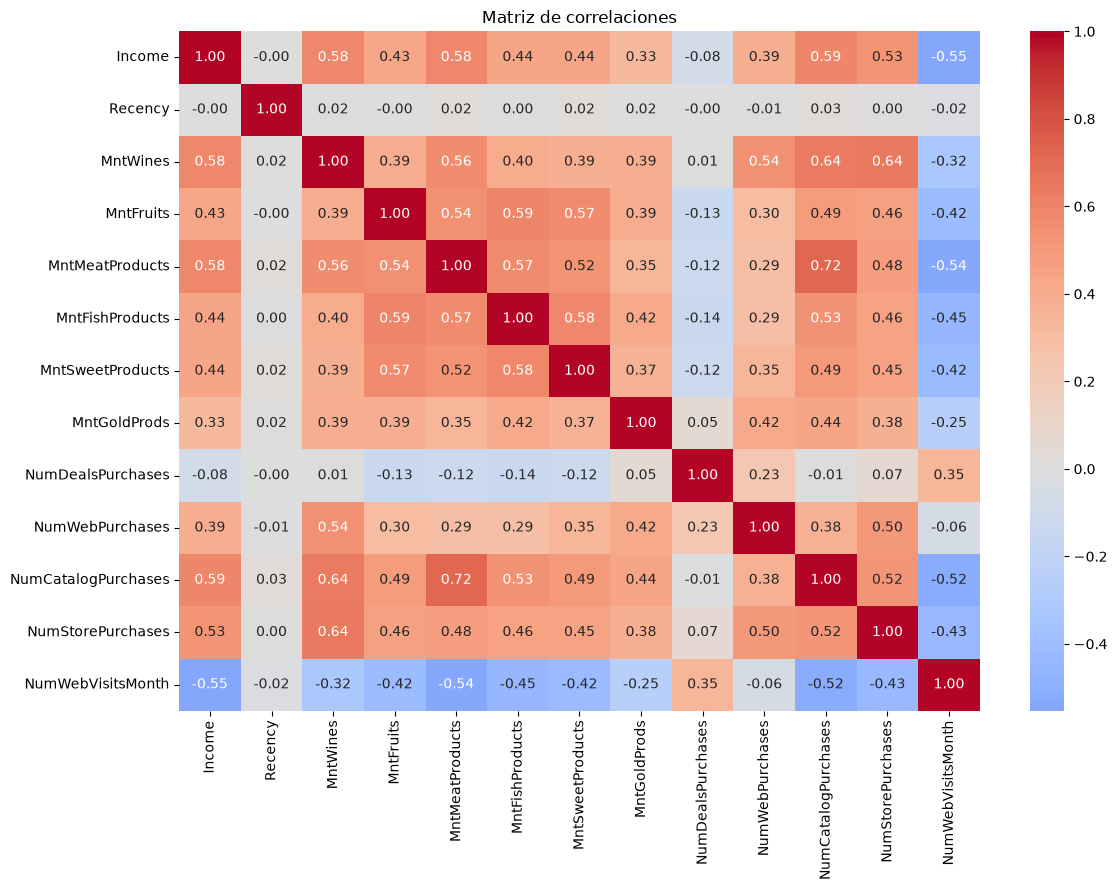

In [41]:
plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de correlaciones")
plt.tight_layout()
plt.show()


### Correlaciones entre variables numéricas

La matriz de correlaciones muestra varios patrones relevantes en el
comportamiento de los clientes.

Las distintas categorías de gasto presentan correlaciones positivas entre sí,
lo que sugiere la existencia de clientes con niveles generales de consumo más
elevados. También se observan asociaciones positivas entre `Income`, el gasto
en determinadas categorías y las compras realizadas por catálogo y tienda.

Entre las relaciones más destacadas se encuentra la existente entre
`MntMeatProducts` y `NumCatalogPurchases` (0,72), así como las relaciones de
`MntWines` con las compras por catálogo y tienda (0,64 en ambos casos).

`NumWebVisitsMonth` presenta asociaciones negativas con varias variables de
gasto, ingresos y compras por otros canales, mientras que su relación con
`NumWebPurchases` es prácticamente nula.

Por otra parte, `Recency` presenta correlaciones cercanas a cero con el resto
de variables analizadas, por lo que parece aportar una dimensión de
comportamiento diferente a las variables relacionadas con gasto y frecuencia.

Estas relaciones son de carácter descriptivo y no implican causalidad.


## 6. Conclusiones

El análisis exploratorio ha permitido identificar los principales patrones,
anomalías y relaciones relevantes para la posterior segmentación de clientes.

### Principales hallazgos

- `Year_Birth` presenta tres observaciones claramente atípicas correspondientes
  a 1893, 1899 y 1900. Su tratamiento se decidirá durante la preparación de
  los datos.

- `Income` contiene 24 valores ausentes y varios valores estadísticamente
  atípicos. Destaca especialmente un ingreso de 666666, muy alejado del resto
  de observaciones y sin un comportamiento de compra proporcionalmente elevado.

- El gasto presenta distribuciones asimétricas hacia valores elevados. Vino y
  productos cárnicos son las categorías con mayor gasto, mientras que las
  distintas categorías de consumo presentan correlaciones positivas entre sí.

- La tienda física es el canal con mayor número medio de compras, seguida del
  canal web y del catálogo. Las compras realizadas con descuento se consideran
  una característica adicional del comportamiento y no un canal independiente.

- No se observa una asociación relevante entre las visitas web del último mes
  y el número de compras web. Las correlaciones de Pearson y Spearman son
  aproximadamente -0,056 y -0,097, respectivamente.

- La última campaña presenta la mayor tasa de respuesta (14,9 %). Los clientes
  que respondieron muestran mayores ingresos y un gasto mediano superior en
  todas las categorías de producto.

- El nivel educativo presenta diferencias descriptivas en la tasa de respuesta.
  `PhD` registra la mayor tasa (20,8 %) y `Basic` la menor (3,7 %).

- `Marital_Status` contiene categorías extremadamente minoritarias (`Alone`,
  `Absurd` y `YOLO`) que deberán revisarse durante la preparación de datos.

- `Recency` se distribuye de forma relativamente uniforme entre 0 y 99 días y
  presenta correlaciones prácticamente nulas con el resto de variables
  cuantitativas, por lo que puede aportar una dimensión diferenciada en la
  futura segmentación RFM.

- La matriz de correlaciones muestra asociaciones entre ingresos, gasto y
  frecuencia de compra. También se observan relaciones negativas entre
  `NumWebVisitsMonth` y varias variables de gasto y comportamiento de compra.

### Implicaciones para la preparación de datos

El EDA identifica varias decisiones que deberán abordarse en la siguiente fase:

1. Tratar los valores ausentes de `Income`.
2. Revisar los tres valores anómalos de `Year_Birth`.
3. Decidir el tratamiento del valor extremo `Income = 666666`.
4. Revisar las categorías minoritarias de `Marital_Status`.
5. Eliminar las variables constantes `Z_CostContact` y `Z_Revenue`.
6. Crear variables derivadas relevantes para segmentación, como edad, número
   de hijos, gasto total y número total de compras.
7. Evaluar el tratamiento de valores extremos antes de aplicar algoritmos
   sensibles a distancias como K-Means.
